# 03.2 — Neuroevolution with Rohemeeter Biodiversity Scores

Extends `03.1` by integrating **spatially-informed biodiversity scoring** from
the [Rohemeeter](https://shiny.botany.ut.ee/rohemeeter/) dataset.

## What's different from 03.1?

- The flat `biodiversity_value` lookup is enhanced with **per-cell Rohemeeter scores**
- Cells with high existing biodiversity get higher protection value
- Cells with low biodiversity and suitable land cover become better restoration candidates
- Wetland restoration is gated by `wetland_suitability` to prevent unrealistic conversions
- This parallels how carbon v1.5 improved the flat carbon model

## Objectives (all minimized internally by NSGA-II)

- Maximize biodiversity gain (now spatially-informed via Rohemeeter)
- Maximize carbon gain (spatially-informed via carbon v1.5)
- Minimize cost
- Minimize total change percentage

In [1]:
import sys
sys.path.insert(0, '../src')

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from estonia_landuse.data.constants import DATA_PROCESSED, COUNTY_NAME, PROJECT_ROOT
from estonia_landuse.data.load import merge_carbon_v15
from estonia_landuse.simulator.config import default_config
from estonia_landuse.simulator.features import derive_features
from estonia_landuse.simulator.simulator import summarize_policy, score_policy
from estonia_landuse.simulator.baselines import (
    policy_no_change, policy_max_forest, policy_restore_wetland, policy_balanced
)
from estonia_landuse.optimizer.trainer import train

## 1. Load Data & Merge Rohemeeter Biodiversity Scores

In [2]:
config = default_config()

# Load base grid and derive features
gdf = gpd.read_file(DATA_PROCESSED / 'base_grid.gpkg')
gdf = derive_features(gdf, config)

# Merge carbon v1.5 scores
gdf = merge_carbon_v15(gdf)

# --- Load Rohemeeter biodiversity scores ---
CARBON_DIR = PROJECT_ROOT / 'data' / 'processed' / 'carbon_v1_5'
rohemeeter_path = CARBON_DIR / 'rohemeeter_scores.parquet'

if rohemeeter_path.exists():
    rohemeeter = pd.read_parquet(rohemeeter_path)
    print(f'Rohemeeter scores: {len(rohemeeter)} cells')
    print(f'  Mean: {rohemeeter["rohemeeter_mean"].mean():.1f}')
    print(f'  Coverage: {rohemeeter["rohemeeter_mean"].notna().sum()} cells with valid data')
    
    # Merge into grid (left join — cells without rohemeeter data get NaN)
    gdf = gdf.merge(rohemeeter[['cell_id', 'rohemeeter_mean', 'rohemeeter_std']], 
                    on='cell_id', how='left')
    
    # Normalize rohemeeter score to 0-1 range (original is 0-100)
    gdf['rohemeeter_norm'] = gdf['rohemeeter_mean'].fillna(50) / 100.0
    print(f'\nMerged. rohemeeter_norm coverage: {gdf["rohemeeter_norm"].notna().sum()}/{len(gdf)} cells')
else:
    print('WARNING: Rohemeeter scores not found. Run 09_fetch_rohemeeter.py first.')
    print('Using flat biodiversity proxy as fallback.')
    gdf['rohemeeter_norm'] = 0.5  # neutral fallback
    gdf['rohemeeter_mean'] = np.nan
    gdf['rohemeeter_std'] = np.nan

Rohemeeter scores: 2504 cells
  Mean: 66.4
  Coverage: 2504 cells with valid data

Merged. rohemeeter_norm coverage: 2806/2806 cells


## 2. Enhanced Biodiversity Scoring

We override the flat biodiversity model with a spatially-informed version:

- **Protection bonus** = existing Rohemeeter score × preservation factor
- **Restoration potential** = (1 - Rohemeeter) × transition value × feasibility
- Wetland restoration is **gated by `wetland_suitability`** to prevent unrealistic mass conversion
- High-biodiversity cells: protect action is rewarded more
- Low-biodiversity cells: restoration actions have more upside (if physically feasible)

In [3]:
def score_policy_biodiversity(context, target_fractions, config=None):
    """Enhanced scorer that uses Rohemeeter for spatially-informed biodiversity."""
    from estonia_landuse.simulator.config import default_config
    
    if config is None:
        config = default_config()
    
    # Get base outcomes from original simulator
    outcomes = score_policy(context, target_fractions, config)
    
    # --- Enhanced biodiversity using Rohemeeter ---
    rohemeeter = context['rohemeeter_norm'].values  # 0-1, higher = better existing biodiversity
    wetland_suit = context['wetland_suitability'].values  # 0-1, physical feasibility
    sc = config.get('scoring', {})
    
    # Current and target fractions
    current = np.column_stack([
        context['forest_pct'].values,
        context['wetland_pct'].values,
        context['agriculture_pct'].values,
        context['grassland_pct'].values,
    ])
    urban = context['urban_pct'].values
    water = context['water_pct'].values
    available_land = np.clip(1.0 - urban - water, 0, 1)
    
    target_sum = target_fractions.sum(axis=1, keepdims=True)
    target_sum = np.where(target_sum > 0, target_sum, 1.0)
    targets = target_fractions / target_sum * available_land[:, None]
    delta = targets - current
    change_pct = outcomes['change_pct'].values
    
    # Base flat biodiversity value per land-use type
    bio_value = np.array(sc.get('biodiversity_value', [0.7, 0.9, 0.2, 0.6]))
    bio_gain_flat = (delta * bio_value[None, :]).sum(axis=1)
    
    # --- Spatially-informed biodiversity gain ---
    
    # 1. Protection bonus: NOT changing high-biodiversity cells
    protection_bonus = (1.0 - change_pct) * rohemeeter * 0.12
    
    # 2. Restoration potential: increasing natural land in LOW-biodiversity cells
    #    BUT gated by physical feasibility!
    restoration_headroom = 1.0 - rohemeeter  # more headroom where biodiversity is low
    forest_gain = np.clip(delta[:, 0], 0, None)
    wetland_gain = np.clip(delta[:, 1], 0, None)
    
    # Afforestation: allowed broadly (most land can support trees)
    forest_restoration = forest_gain * 0.6 * restoration_headroom
    
    # Wetland restoration: MUST be gated by wetland_suitability
    # Only cells with actual wetland suitability get biodiversity credit
    wetland_restoration = wetland_gain * 0.8 * restoration_headroom * wetland_suit
    
    restoration_gain = forest_restoration + wetland_restoration
    
    # 3. Destruction penalty: reducing natural land in HIGH-biodiversity cells
    forest_loss = np.clip(-delta[:, 0], 0, None)
    wetland_loss = np.clip(-delta[:, 1], 0, None)
    destruction_penalty = (forest_loss * 0.6 + wetland_loss * 0.9) * rohemeeter
    
    # 4. Connectivity bonus from protected areas (same as original)
    protected = context['protected_overlap_pct'].values
    connectivity_bonus = sc.get('connectivity_bonus', 0.2) * change_pct * protected
    
    # Combine: blend flat + spatial (60% spatial, 40% flat)
    bio_gain_spatial = protection_bonus + restoration_gain - destruction_penalty + connectivity_bonus
    biodiversity_gain = 0.4 * bio_gain_flat + 0.6 * bio_gain_spatial
    
    # Apply protected area constraint (same as original)
    protected_threshold = config.get('constraints', {}).get('protected_pct_blocks_change', 0.8)
    is_protected = protected > protected_threshold
    biodiversity_gain[is_protected] = 0.0
    
    # Replace biodiversity_gain in outcomes
    outcomes['biodiversity_gain'] = biodiversity_gain
    return outcomes


def summarize_policy_biodiversity(context, target_fractions, config=None):
    """Summarize with enhanced biodiversity scoring."""
    if config is None:
        config = default_config()
    outcomes = score_policy_biodiversity(context, target_fractions, config)
    changed_pct = outcomes['change_pct'].mean()
    max_changed = config.get('max_changed_pct', 0.25)
    budget_weight = config.get('budget_penalty_weight', 2.0)
    budget_penalty = max(0.0, changed_pct - max_changed) * budget_weight
    return {
        'biodiversity_gain': outcomes['biodiversity_gain'].mean(),
        'carbon_gain': outcomes['carbon_gain'].mean(),
        'cost': outcomes['cost'].mean() + budget_penalty,
        'constraint_penalty': outcomes['constraint_penalty'].mean(),
        'changed_pct': changed_pct,
    }

print('Enhanced biodiversity scoring functions defined.')

Enhanced biodiversity scoring functions defined.


## 3. Feature Setup

We add `rohemeeter_norm` as an input feature so the prescriptor can learn
to use local biodiversity context when deciding actions.

In [4]:
FEATURE_COLS = [
    'forest_pct', 'wetland_pct', 'agriculture_pct', 'urban_pct',
    'water_pct', 'grassland_pct',
    'naturalness_score', 'carbon_score',
    'protected_overlap_pct', 'road_density_km', 'building_count',
    'wetland_suitability', 'biodiversity_proxy', 'opportunity_cost_proxy',
    'rohemeeter_norm',  # NEW: spatially-informed biodiversity
]
gdf[FEATURE_COLS] = gdf[FEATURE_COLS].fillna(0)
print(f'{len(gdf)} cells, {len(FEATURE_COLS)} features')
print(f'Rohemeeter stats: mean={gdf["rohemeeter_norm"].mean():.3f}, '
      f'std={gdf["rohemeeter_norm"].std():.3f}')
print(f'Wetland suitability stats: mean={gdf["wetland_suitability"].mean():.3f}, '
      f'max={gdf["wetland_suitability"].max():.3f}')

2806 cells, 15 features
Rohemeeter stats: mean=0.646, std=0.208
Wetland suitability stats: mean=0.342, max=1.000


## 4. Baselines (with enhanced biodiversity scoring)

In [5]:
baselines = {
    'No change': policy_no_change(gdf),
    'Max forest': policy_max_forest(gdf),
    'Restore wetland': policy_restore_wetland(gdf),
    'Balanced': policy_balanced(gdf),
}

baseline_results = []
for name, target in baselines.items():
    s = summarize_policy_biodiversity(gdf, target, config)
    s['policy'] = name
    baseline_results.append(s)

baseline_df = pd.DataFrame(baseline_results).set_index('policy')
print(baseline_df.to_string(float_format='{:.4f}'.format))

                 biodiversity_gain  carbon_gain   cost  constraint_penalty  changed_pct
policy                                                                                 
No change                   0.0332       0.0288 0.0009              0.0136       0.0029
Max forest                  0.0580       0.0564 0.7926              0.6942       0.1035
Restore wetland             0.0373       0.0290 0.0387              0.5238       0.0195
Balanced                    0.0465       0.0376 0.1121              0.9968       0.0499


## 5. Run Evolution

We use a patched trainer that calls our enhanced biodiversity scoring.

In [6]:
from estonia_landuse.optimizer.prescriptor import Prescriptor
from estonia_landuse.optimizer.nsga2 import fast_non_dominated_sort, crowding_distance
from estonia_landuse.optimizer.seeds import create_seed_prescriptors


def _evaluate_population_bio(population, features_norm, context, config):
    """Evaluate fitness using enhanced biodiversity scoring."""
    for p in population:
        target_fractions = p.prescribe(features_norm)
        summary = summarize_policy_biodiversity(context, target_fractions, config)
        # NSGA-II minimizes all objectives
        p.metrics = (
            -summary['biodiversity_gain'],
            -summary['carbon_gain'],
            summary['cost'],
            summary['changed_pct'],
        )


def train_biodiversity(
    context, feature_columns, pop_size=100, n_generations=100,
    hidden_size=16, p_mutation=0.2, mutation_factor=0.1,
    config=None, use_seeds=True, verbose=True,
):
    """NSGA-II evolution with enhanced biodiversity scoring."""
    from estonia_landuse.optimizer.trainer import _create_offspring, _select
    
    in_size = len(feature_columns)
    features = context[feature_columns].values.astype(np.float32)
    feat_mean = features.mean(axis=0)
    feat_std = features.std(axis=0)
    feat_std[feat_std == 0] = 1.0
    features_norm = (features - feat_mean) / feat_std
    
    if use_seeds:
        seeds = create_seed_prescriptors(features_norm, context, hidden_size=hidden_size)
        if verbose:
            print(f'Created {len(seeds)} seed prescriptors')
        n_random = max(0, pop_size - len(seeds))
        population = seeds + [Prescriptor(in_size, hidden_size) for _ in range(n_random)]
    else:
        population = [Prescriptor(in_size, hidden_size) for _ in range(pop_size)]
    
    _evaluate_population_bio(population, features_norm, context, config)
    
    for gen in range(n_generations):
        offspring = _create_offspring(population, pop_size, p_mutation, mutation_factor)
        _evaluate_population_bio(offspring, features_norm, context, config)
        combined = population + offspring
        population = _select(combined, pop_size)
        
        if verbose and (gen + 1) % 10 == 0:
            front0 = [p for p in population if p.rank == 0]
            avg_metrics = np.mean([p.metrics for p in front0], axis=0)
            print(f'Gen {gen+1:>3d} | Front-0: {len(front0):>3d} | '
                  f'Avg: bio={-avg_metrics[0]:.4f} carbon={-avg_metrics[1]:.4f} '
                  f'cost={avg_metrics[2]:.4f} change={avg_metrics[3]:.1%}')
    
    population.sort(key=lambda p: (p.rank, -getattr(p, 'crowding', 0)))
    return population

print('Custom trainer defined.')

Custom trainer defined.


In [7]:
population = train_biodiversity(
    context=gdf,
    feature_columns=FEATURE_COLS,
    pop_size=100,
    n_generations=130,
    hidden_size=16,
    p_mutation=0.2,
    mutation_factor=0.1,
    config=config,
    use_seeds=True,
    verbose=True,
)
front0 = [p for p in population if p.rank == 0]
print(f'\nPareto front: {len(front0)} policies')

C:\Users\risto\projects\et-landuse-neuroevolution\notebooks\../src\estonia_landuse\optimizer\seeds.py:42: RuntimeWarning: invalid value encountered in divide
  current_norm = np.where(current_sum > 0, current / current_sum, 0.25)


Created 4 seed prescriptors
Gen  10 | Front-0:  20 | Avg: bio=0.0251 carbon=-0.0012 cost=1.2931 change=36.9%
Gen  20 | Front-0:  36 | Avg: bio=0.0447 carbon=0.0292 cost=1.2358 change=31.5%
Gen  30 | Front-0:  85 | Avg: bio=0.0546 carbon=0.0431 cost=1.1753 change=28.4%
Gen  40 | Front-0: 100 | Avg: bio=0.0549 carbon=0.0483 cost=1.0941 change=26.5%
Gen  50 | Front-0: 100 | Avg: bio=0.0551 carbon=0.0507 cost=1.0726 change=25.3%
Gen  60 | Front-0: 100 | Avg: bio=0.0547 carbon=0.0515 cost=1.0890 change=25.1%
Gen  70 | Front-0: 100 | Avg: bio=0.0537 carbon=0.0509 cost=1.0858 change=24.6%
Gen  80 | Front-0: 100 | Avg: bio=0.0530 carbon=0.0519 cost=1.0733 change=24.8%
Gen  90 | Front-0: 100 | Avg: bio=0.0542 carbon=0.0524 cost=1.1046 change=24.4%
Gen 100 | Front-0: 100 | Avg: bio=0.0548 carbon=0.0532 cost=1.1058 change=24.5%
Gen 110 | Front-0: 100 | Avg: bio=0.0552 carbon=0.0536 cost=1.1015 change=24.4%
Gen 120 | Front-0: 100 | Avg: bio=0.0584 carbon=0.0572 cost=1.1746 change=25.0%
Gen 130 | F

## 6. Pareto Front Analysis

In [8]:
# Evaluate all Pareto front members
feat = gdf[FEATURE_COLS].values.astype(np.float32)
feat_norm = (feat - feat.mean(0)) / (feat.std(0) + 1e-8)

pareto_results = []
for i, p in enumerate(front0):
    targets = p.prescribe(feat_norm)
    s = summarize_policy_biodiversity(gdf, targets, config)
    s['id'] = i
    pareto_results.append(s)

pareto_df = pd.DataFrame(pareto_results)
print(f'Changed range: {pareto_df["changed_pct"].min():.1%} - {pareto_df["changed_pct"].max():.1%}')
print(f'Bio gain range: {pareto_df["biodiversity_gain"].min():.4f} - {pareto_df["biodiversity_gain"].max():.4f}')
print(f'Carbon range: {pareto_df["carbon_gain"].min():.4f} - {pareto_df["carbon_gain"].max():.4f}')

Changed range: 13.1% - 35.6%
Bio gain range: 0.0074 - 0.0874
Carbon range: 0.0075 - 0.0951


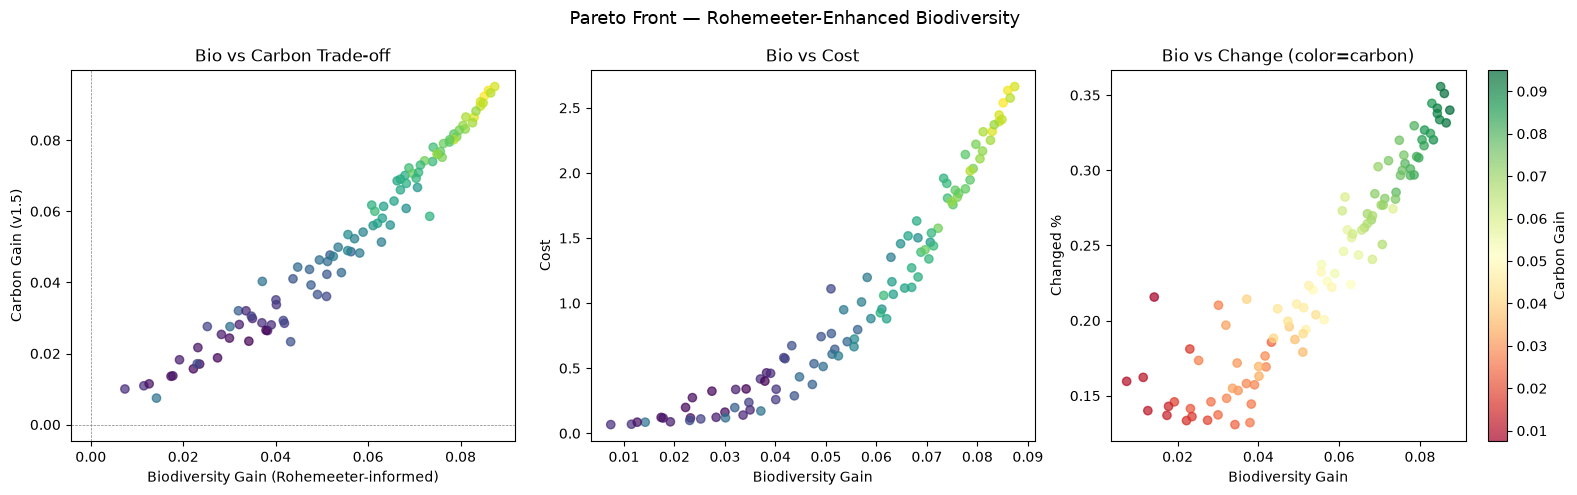

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bio vs Carbon
axes[0].scatter(pareto_df['biodiversity_gain'], pareto_df['carbon_gain'],
               c=pareto_df['changed_pct'], cmap='viridis', alpha=0.7)
axes[0].set_xlabel('Biodiversity Gain (Rohemeeter-informed)')
axes[0].set_ylabel('Carbon Gain (v1.5)')
axes[0].set_title('Bio vs Carbon Trade-off')
axes[0].axhline(0, color='gray', ls='--', lw=0.5)
axes[0].axvline(0, color='gray', ls='--', lw=0.5)

# Bio vs Cost
axes[1].scatter(pareto_df['biodiversity_gain'], pareto_df['cost'],
               c=pareto_df['changed_pct'], cmap='viridis', alpha=0.7)
axes[1].set_xlabel('Biodiversity Gain')
axes[1].set_ylabel('Cost')
axes[1].set_title('Bio vs Cost')

# Bio vs Change %
sc = axes[2].scatter(pareto_df['biodiversity_gain'], pareto_df['changed_pct'],
               c=pareto_df['carbon_gain'], cmap='RdYlGn', alpha=0.7)
axes[2].set_xlabel('Biodiversity Gain')
axes[2].set_ylabel('Changed %')
axes[2].set_title('Bio vs Change (color=carbon)')
plt.colorbar(sc, ax=axes[2], label='Carbon Gain')

plt.suptitle('Pareto Front — Rohemeeter-Enhanced Biodiversity', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Visualize Best Policy

Pick the policy with best biodiversity gain and map its land-use changes.

In [10]:
# Pick best biodiversity policy
best_bio_idx = pareto_df['biodiversity_gain'].idxmax()
best_policy = front0[best_bio_idx]
best_targets = best_policy.prescribe(feat_norm)

# Compute per-cell outcomes
best_outcomes = score_policy_biodiversity(gdf, best_targets, config)

# Add outcomes to geodataframe for plotting
plot_gdf = gdf[['geometry', 'cell_id', 'rohemeeter_norm', 'wetland_suitability']].copy()
plot_gdf['biodiversity_gain'] = best_outcomes['biodiversity_gain'].values
plot_gdf['carbon_gain'] = best_outcomes['carbon_gain'].values
plot_gdf['change_pct'] = best_outcomes['change_pct'].values

# Dominant action per cell
groups = ['forest', 'wetland', 'agriculture', 'grassland']
current = np.column_stack([gdf[f'{g}_pct'].values for g in groups])
delta = best_targets - current
dominant_action = np.where(
    np.abs(delta).max(axis=1) < 0.05, 'no_change',
    np.array(['afforest', 'restore_wetland', 'to_agriculture', 'to_grassland'])[delta.argmax(axis=1)]
)
plot_gdf['dominant_action'] = dominant_action

print(f'Best biodiversity policy (id={best_bio_idx}):')
print(f'  Bio gain: {pareto_df.loc[best_bio_idx, "biodiversity_gain"]:.4f}')
print(f'  Carbon gain: {pareto_df.loc[best_bio_idx, "carbon_gain"]:.4f}')
print(f'  Cost: {pareto_df.loc[best_bio_idx, "cost"]:.4f}')
print(f'  Changed: {pareto_df.loc[best_bio_idx, "changed_pct"]:.1%}')
print(f'\nAction distribution:')
print(pd.Series(dominant_action).value_counts())

Best biodiversity policy (id=1):
  Bio gain: 0.0874
  Carbon gain: 0.0951
  Cost: 2.6637
  Changed: 34.0%

Action distribution:
afforest           1807
no_change           617
restore_wetland     209
to_agriculture      170
to_grassland          3
Name: count, dtype: int64


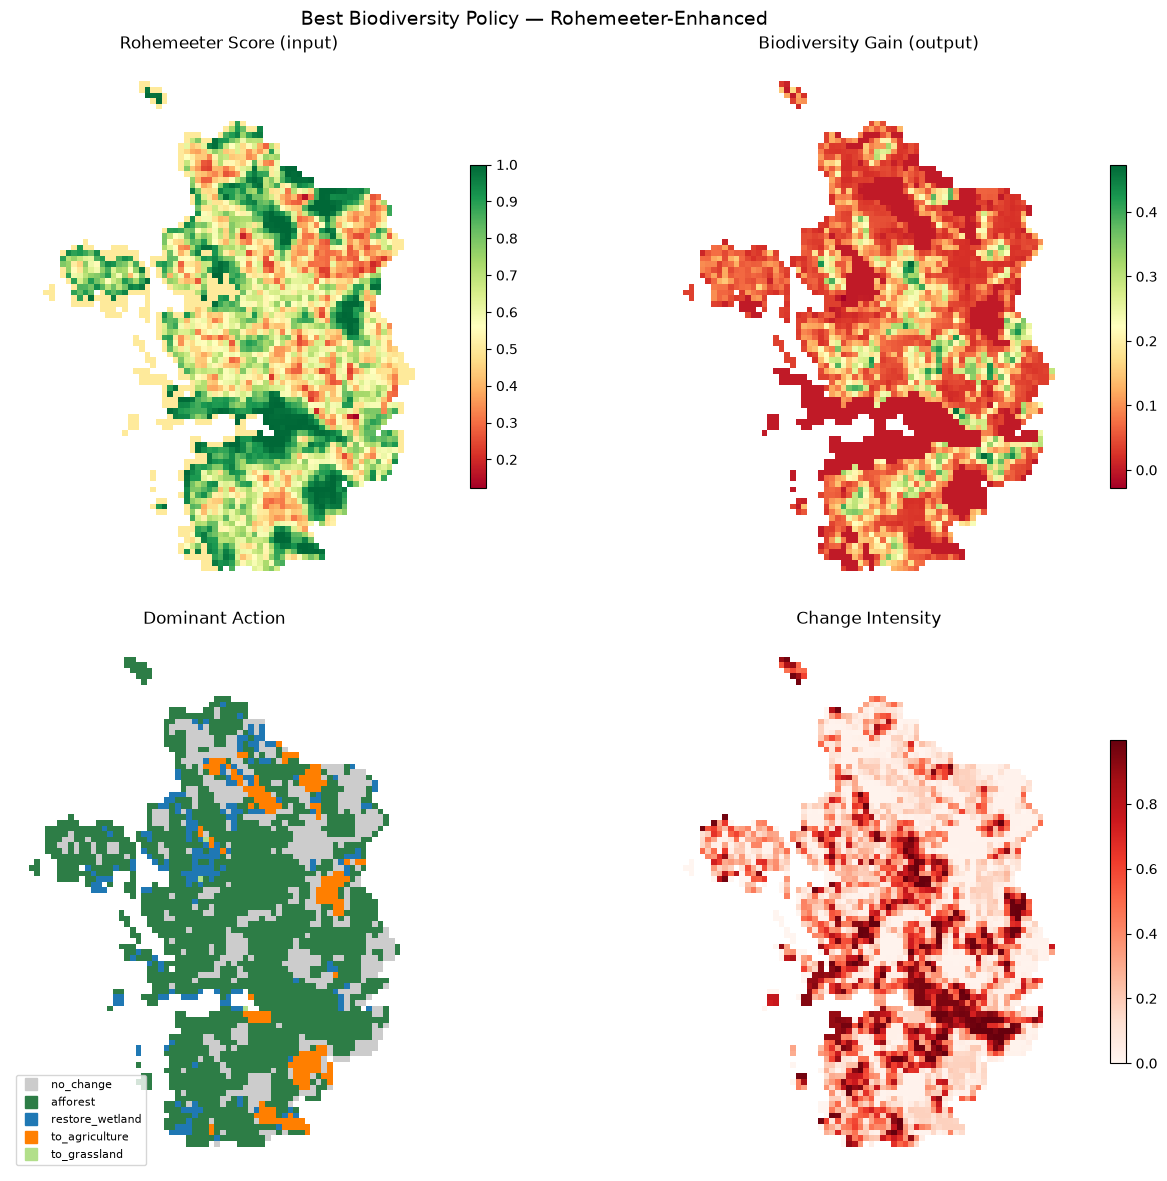

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Rohemeeter input
plot_gdf.plot(column='rohemeeter_norm', ax=axes[0, 0], legend=True, cmap='RdYlGn',
             legend_kwds={'shrink': 0.6})
axes[0, 0].set_title('Rohemeeter Score (input)')
axes[0, 0].set_axis_off()

# Biodiversity gain
plot_gdf.plot(column='biodiversity_gain', ax=axes[0, 1], legend=True, cmap='RdYlGn',
             legend_kwds={'shrink': 0.6})
axes[0, 1].set_title('Biodiversity Gain (output)')
axes[0, 1].set_axis_off()

# Dominant action
action_colors = {
    'no_change': '#cccccc',
    'afforest': '#2d7d46',
    'restore_wetland': '#1f78b4',
    'to_agriculture': '#ff7f00',
    'to_grassland': '#b2df8a',
}
plot_gdf['action_color'] = plot_gdf['dominant_action'].map(action_colors)
plot_gdf.plot(color=plot_gdf['action_color'], ax=axes[1, 0])
axes[1, 0].set_title('Dominant Action')
axes[1, 0].set_axis_off()
# Legend
for action, color in action_colors.items():
    axes[1, 0].plot([], [], 's', color=color, label=action, markersize=8)
axes[1, 0].legend(loc='lower left', fontsize=8)

# Change %
plot_gdf.plot(column='change_pct', ax=axes[1, 1], legend=True, cmap='Reds',
             legend_kwds={'shrink': 0.6})
axes[1, 1].set_title('Change Intensity')
axes[1, 1].set_axis_off()

plt.suptitle('Best Biodiversity Policy — Rohemeeter-Enhanced', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Comparison: Flat vs Rohemeeter-Informed Biodiversity

Compare the evolved policies against the same baselines scored with the original flat model.

In [12]:
# Score baselines with both models
comparison = []
for name, target in baselines.items():
    s_flat = summarize_policy(gdf, target, config)
    s_bio = summarize_policy_biodiversity(gdf, target, config)
    comparison.append({
        'policy': name,
        'bio_flat': s_flat['biodiversity_gain'],
        'bio_rohemeeter': s_bio['biodiversity_gain'],
        'carbon': s_flat['carbon_gain'],
        'cost': s_flat['cost'],
    })

comp_df = pd.DataFrame(comparison).set_index('policy')
print('Baseline comparison: flat vs Rohemeeter-informed biodiversity scoring')
print(comp_df.to_string(float_format='{:.4f}'.format))
print()
print('Note: Differences show how spatial biodiversity data changes policy evaluation.')
print('Policies that protect high-Rohemeeter areas score better with the new model.')

Baseline comparison: flat vs Rohemeeter-informed biodiversity scoring
                 bio_flat  bio_rohemeeter  carbon   cost
policy                                                  
No change          0.0013          0.0332  0.0288 0.0009
Max forest         0.0390          0.0580  0.0564 0.7926
Restore wetland    0.0113          0.0373  0.0290 0.0387
Balanced           0.0264          0.0465  0.0376 0.1121

Note: Differences show how spatial biodiversity data changes policy evaluation.
Policies that protect high-Rohemeeter areas score better with the new model.


# 9. Total gains

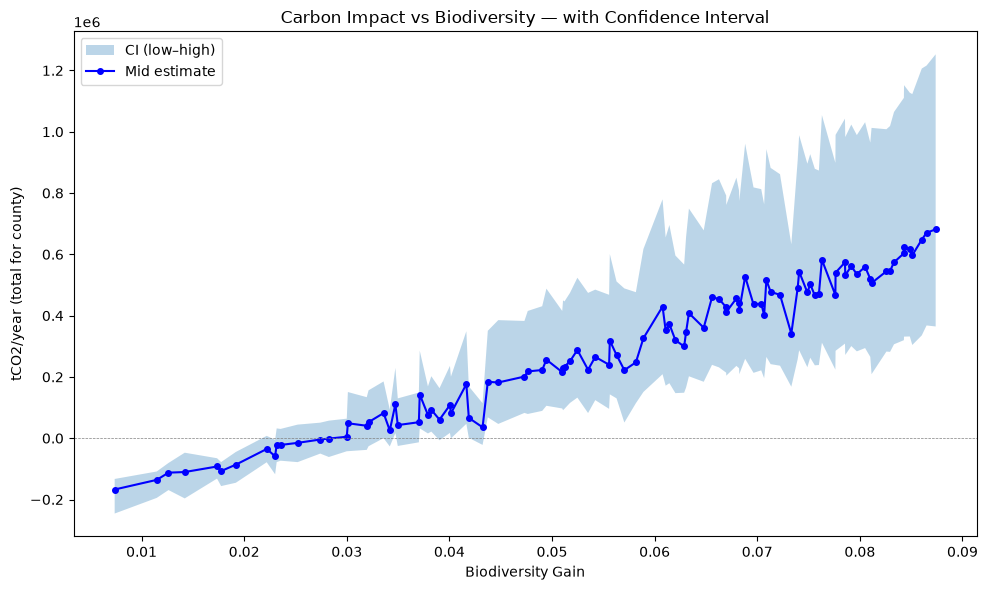

In [13]:
from estonia_landuse.simulator.carbon_tonnes import summarize_carbon_tonnes, estimate_carbon_tonnes_ci

# Get CI for multiple Pareto front policies
results_ci = []
for i, p in enumerate(front0):
    targets = p.prescribe(feat_norm)
    ci = estimate_carbon_tonnes_ci(gdf, targets)
    results_ci.append({
        'id': i,
        'tco2_low': ci['low']['total_tco2_per_year'],
        'tco2_mid': ci['mid']['total_tco2_per_year'],
        'tco2_high': ci['high']['total_tco2_per_year'],
        'bio_gain': pareto_df.loc[i, 'biodiversity_gain'],
    })

ci_df = pd.DataFrame(results_ci).sort_values('bio_gain')

# Plot with confidence interval
fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(ci_df['bio_gain'], ci_df['tco2_low'], ci_df['tco2_high'],
                alpha=0.3, label='CI (low–high)')
ax.plot(ci_df['bio_gain'], ci_df['tco2_mid'], 'b-o', markersize=4, label='Mid estimate')
ax.set_xlabel('Biodiversity Gain')
ax.set_ylabel('tCO2/year (total for county)')
ax.set_title('Carbon Impact vs Biodiversity — with Confidence Interval')
ax.legend()
ax.axhline(0, color='gray', ls='--', lw=0.5)
plt.tight_layout()
plt.show()


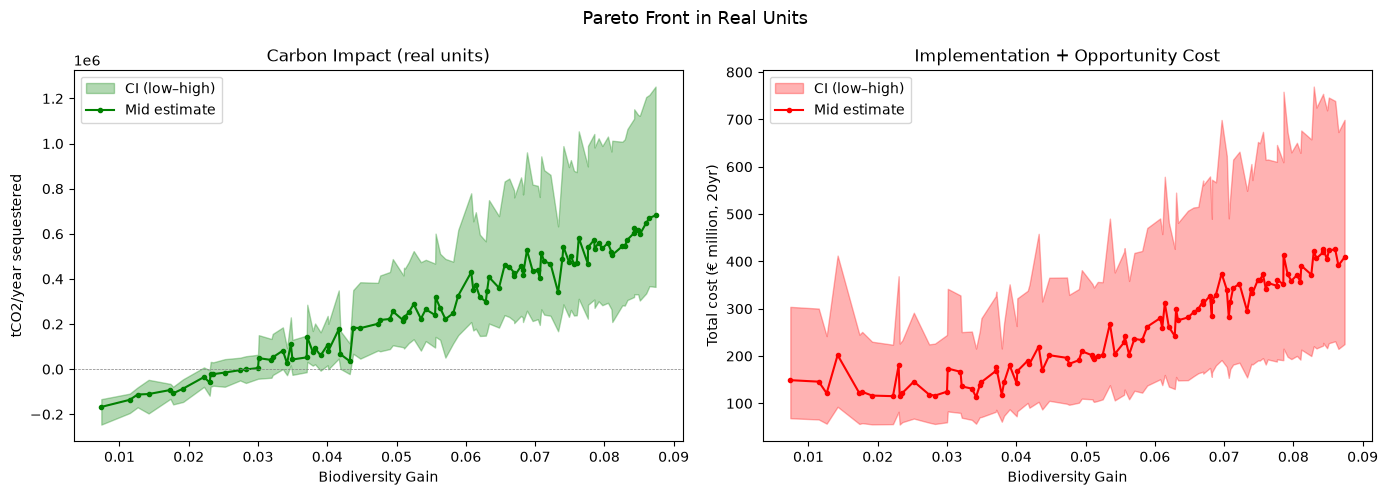

In [14]:
from estonia_landuse.simulator.carbon_tonnes import estimate_carbon_tonnes_ci
from estonia_landuse.simulator.cost_eur import estimate_cost_eur_ci

# Evaluate all Pareto front policies
results = []
for i, p in enumerate(front0):
    targets = p.prescribe(feat_norm)
    carbon_ci = estimate_carbon_tonnes_ci(gdf, targets)
    cost_ci = estimate_cost_eur_ci(gdf, targets)
    results.append({
        'id': i,
        'bio_gain': pareto_df.loc[i, 'biodiversity_gain'],
        'tco2_low': carbon_ci['low']['total_tco2_per_year'],
        'tco2_mid': carbon_ci['mid']['total_tco2_per_year'],
        'tco2_high': carbon_ci['high']['total_tco2_per_year'],
        'cost_low': cost_ci['low']['total_cost_eur'] / 1e6,
        'cost_mid': cost_ci['mid']['total_cost_eur'] / 1e6,
        'cost_high': cost_ci['high']['total_cost_eur'] / 1e6,
    })

rdf = pd.DataFrame(results).sort_values('bio_gain')

# Plot carbon with CI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].fill_between(rdf['bio_gain'], rdf['tco2_low'], rdf['tco2_high'],
                     alpha=0.3, color='green', label='CI (low–high)')
axes[0].plot(rdf['bio_gain'], rdf['tco2_mid'], 'g-o', ms=3, label='Mid estimate')
axes[0].set_xlabel('Biodiversity Gain')
axes[0].set_ylabel('tCO2/year sequestered')
axes[0].set_title('Carbon Impact (real units)')
axes[0].legend()
axes[0].axhline(0, color='gray', ls='--', lw=0.5)

# Plot cost with CI
axes[1].fill_between(rdf['bio_gain'], rdf['cost_low'], rdf['cost_high'],
                     alpha=0.3, color='red', label='CI (low–high)')
axes[1].plot(rdf['bio_gain'], rdf['cost_mid'], 'r-o', ms=3, label='Mid estimate')
axes[1].set_xlabel('Biodiversity Gain')
axes[1].set_ylabel('Total cost (€ million, 20yr)')
axes[1].set_title('Implementation + Opportunity Cost')
axes[1].legend()

plt.suptitle('Pareto Front in Real Units', fontsize=13)
plt.tight_layout()
plt.show()


## Summary

This notebook demonstrates how integrating **real biodiversity data** (Rohemeeter)
changes the optimization landscape:

- The prescriptor network now receives local biodiversity context as an input feature
- The scoring function rewards protecting high-biodiversity cells and restoring low-biodiversity ones
- **Wetland restoration is gated by physical suitability** — preventing unrealistic mass conversion
- The Pareto front reflects more ecologically meaningful trade-offs
- Evolved policies are spatially aware — they concentrate restoration where it matters most

### Next steps

- Increase `pop_size` and `n_generations` for better convergence
- Tune the blend factor (currently 60% spatial, 40% flat)
- Add Rohemeeter uncertainty (`rohemeeter_std`) as a confidence weight
- Visualize in the Streamlit dashboard